In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import joblib

In [3]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/royhridoy965-sketch/AI-and-ML-Lab/main/CART_ID3/dataset/Iris1.csv"
)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
X = df.drop('Species', axis=1)

X.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,1,5.1,3.5,1.4,0.2
1,2,4.9,3.0,1.4,0.2
2,3,4.7,3.2,1.3,0.2
3,4,4.6,3.1,1.5,0.2
4,5,5.0,3.6,1.4,0.2


In [5]:
X = df.drop(['Id','Species'], axis=1)

In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [7]:
wcss = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

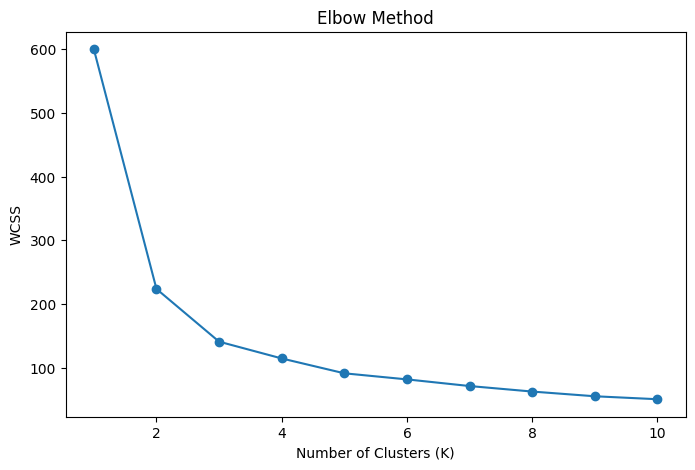

In [8]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [9]:
optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [27]:
import os

model_save_dir = "/content/KMeans_Project/model"
dataset_save_dir = "/content/KMeans_Project/dataset"

os.makedirs(model_save_dir, exist_ok=True)
os.makedirs(dataset_save_dir, exist_ok=True)


In [28]:
joblib.dump(
    kmeans,
    os.path.join(model_save_dir, "190110_kmeans.pkl")
)

['/content/KMeans_Project/model/190110_kmeans.pkl']

In [29]:
joblib.dump(
    scaler,
    os.path.join(model_save_dir, "scaler.pkl")
)

['/content/KMeans_Project/model/scaler.pkl']

In [30]:
joblib.dump(
    kmeans,
    "/content/KMeans_Project/model/190110_kmeans.pkl"
)

['/content/KMeans_Project/model/190110_kmeans.pkl']

In [26]:
import os

# Ensure the model directory exists
model_save_dir = "/content/KMeans_Project/model"
os.makedirs(model_save_dir, exist_ok=True)

# Save the scaler
joblib.dump(
    scaler,
    os.path.join(model_save_dir, "scaler.pkl")
)

print(f"Scaler saved successfully to: {os.path.join(model_save_dir, 'scaler.pkl')}")

Scaler saved successfully to: /content/KMeans_Project/model/scaler.pkl


In [24]:
df['Cluster'] = kmeans.labels_

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Cluster
0,1,5.1,3.5,1.4,0.2,Iris-setosa,1
1,2,4.9,3.0,1.4,0.2,Iris-setosa,1
2,3,4.7,3.2,1.3,0.2,Iris-setosa,1
3,4,4.6,3.1,1.5,0.2,Iris-setosa,1
4,5,5.0,3.6,1.4,0.2,Iris-setosa,1


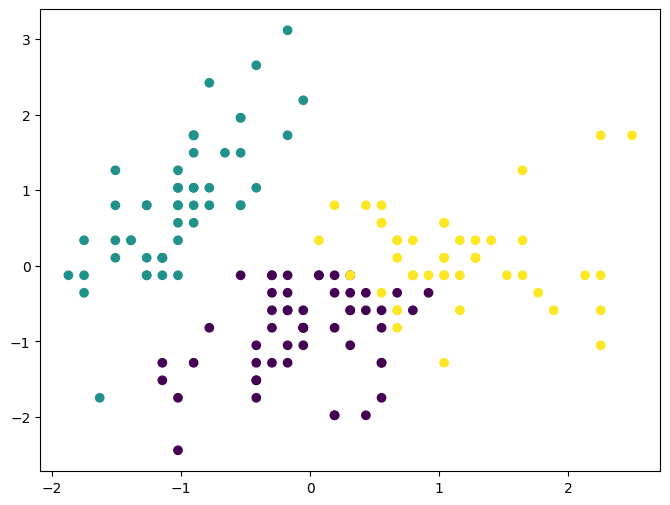

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=kmeans.labels_,
    cmap='viridis'
)

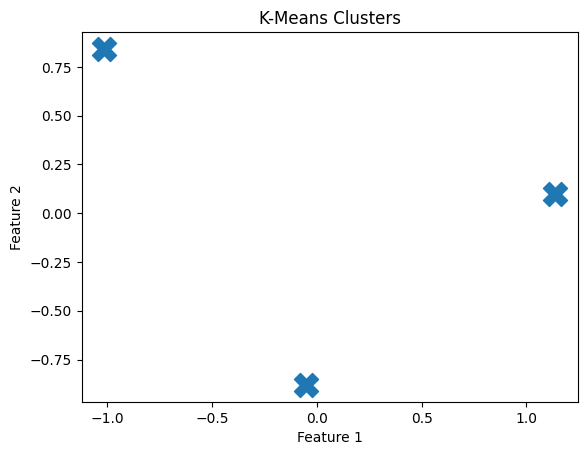

In [22]:
centroids = kmeans.cluster_centers_

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    s=300,
    marker='X'
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clusters")

plt.show()

In [20]:
import os
import pandas as pd

# Ensure directory exists
os.makedirs('/content/KMeans_Project/dataset/', exist_ok=True)

# Placeholder: Since custom_leaf.csv was not provided, I will create a sample for you to run the rest of the code.
data = {
    'SepalLengthCm': [5.1, 6.2],
    'SepalWidthCm': [3.5, 3.4],
    'PetalLengthCm': [1.4, 5.4],
    'PetalWidthCm': [0.2, 2.3]
}
custom_df = pd.DataFrame(data)

# If you have the actual file, uncomment the line below:
# custom_df = pd.read_csv('/content/KMeans_Project/dataset/custom_leaf.csv')

custom_df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,6.2,3.4,5.4,2.3


In [14]:
custom_scaled = scaler.transform(
    custom_df
)

In [15]:
custom_clusters = kmeans.predict(
    custom_scaled
)

custom_df['Cluster_ID'] = custom_clusters

In [16]:
custom_df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Cluster_ID
0,5.1,3.5,1.4,0.2,1
1,6.2,3.4,5.4,2.3,2


In [17]:
centroid_df = pd.DataFrame(
    scaler.inverse_transform(
        kmeans.cluster_centers_
    ),
    columns=X.columns
)

centroid_df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.801887,2.673585,4.369811,1.413208
1,5.006000,3.418000,1.464000,0.244000
2,6.780851,3.095745,5.510638,1.972340


In [18]:
custom_df.to_csv(
    "/content/KMeans_Project/dataset/custom_prediction.csv",
    index=False
)

print(centroid_df)

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0       5.801887      2.673585       4.369811      1.413208
1       5.006000      3.418000       1.464000      0.244000
2       6.780851      3.095745       5.510638      1.972340


In [21]:
import os

dataset_save_dir = "/content/KMeans_Project/dataset"
os.makedirs(dataset_save_dir, exist_ok=True)

custom_df.to_csv(
    os.path.join(dataset_save_dir, "custom_prediction.csv"),
    index=False
)

print(f"File saved successfully to: {os.path.join(dataset_save_dir, 'custom_prediction.csv')}")

File saved successfully to: /content/KMeans_Project/dataset/custom_prediction.csv


The model, scaler, and custom prediction results have been saved to the `/content/KMeans_Project/model/` and `/content/KMeans_Project/dataset/` directories respectively.